<a href="https://colab.research.google.com/github/Shivam250124/Machine_Learning-/blob/main/MultiClass_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>IRIS DATASET: Logistic Regression</h2>


<img width=200 height = 200 src="iris.png"/>


###Load DataSet


In [30]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [31]:
from sklearn.datasets import load_iris
iris=load_iris(as_frame= True)
df=iris.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
df['target_name']=df.target.map({0:'setosa',1:'versicolor',2:'virginica'})
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
53,5.5,2.3,4.0,1.3,1,versicolor
90,5.5,2.6,4.4,1.2,1,versicolor
49,5.0,3.3,1.4,0.2,0,setosa
20,5.4,3.4,1.7,0.2,0,setosa
79,5.7,2.6,3.5,1.0,1,versicolor


In [33]:
df.shape

(150, 6)

In [34]:
df.target.unique()

array([0, 1, 2])

In [35]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [36]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [37]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

###Data Visualization


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

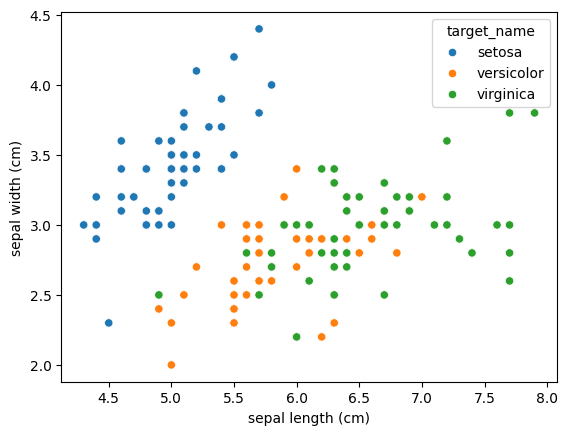

In [39]:
sns.scatterplot(df,x="sepal length (cm)",y="sepal width (cm)",hue="target_name")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

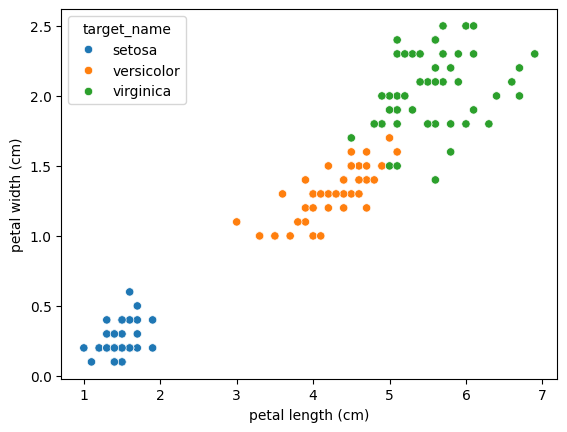

In [40]:
sns.scatterplot(df,x="petal length (cm)",y="petal width (cm)",hue="target_name")

In [41]:
X=df[["sepal length (cm)","sepal width (cm)","petal length (cm)","petal width (cm)"]]
y=df[["target"]]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


###Model Training



In [43]:
#Split dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=5)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [48]:
#Split dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=5)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=200)

###Model Evaluation


In [49]:
model.score(X_test,y_test)

0.9777777777777777

In [51]:
y_pred=model.predict(X_test)


In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9777777777777777

In [54]:
y_pred[:10].tolist()

[1, 2, 2, 0, 2, 1, 0, 2, 0, 1]

In [58]:
y_test['target'][:10].tolist()

[1, 2, 2, 0, 2, 1, 0, 1, 0, 1]

###Model Evaluation : Precision , Recall , F1 Score

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        16
           2       0.93      1.00      0.97        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



###Model Evaluation : Confussion Matrix

In [62]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[15,  0,  0],
       [ 0, 15,  1],
       [ 0,  0, 14]])

Text(0.5, 1.0, 'Confusion Matrix')

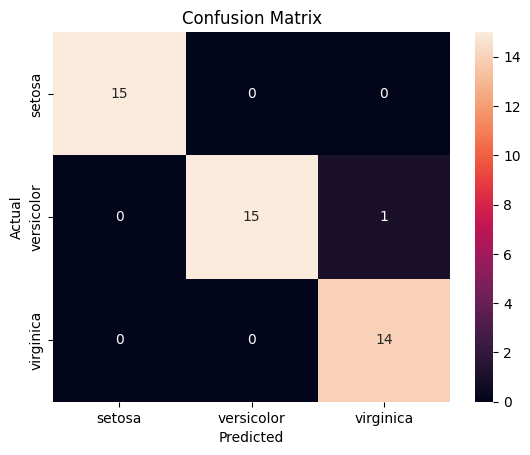

In [63]:
sns.heatmap(cm,xticklabels=iris.target_names,yticklabels=iris.target_names,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')